In [1]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from collections import Counter
from bisect import bisect_left, bisect_right

In [2]:
# ---------------------------
# 1. Parse the XML file
# ---------------------------

tree = ET.parse("patients.xml")
root = tree.getroot()

patients = root.findall(".//patient")

# Keep strings for checking EXACT duplicates
age_strings = [
    patient.get("age")
    for patient in patients
    if patient.get("age") is not None
]

# Convert to float for numerical analysis / histogram
ages = [float(age) for age in age_strings]

print("Number of patients:", len(patients))
print("Number of ages:", len(ages))
print("Minimum age:", min(ages))
print("Maximum age:", max(ages))

Number of patients: 324357
Number of ages: 324357
Minimum age: 0.00010629282758800596
Maximum age: 84.99855742449432


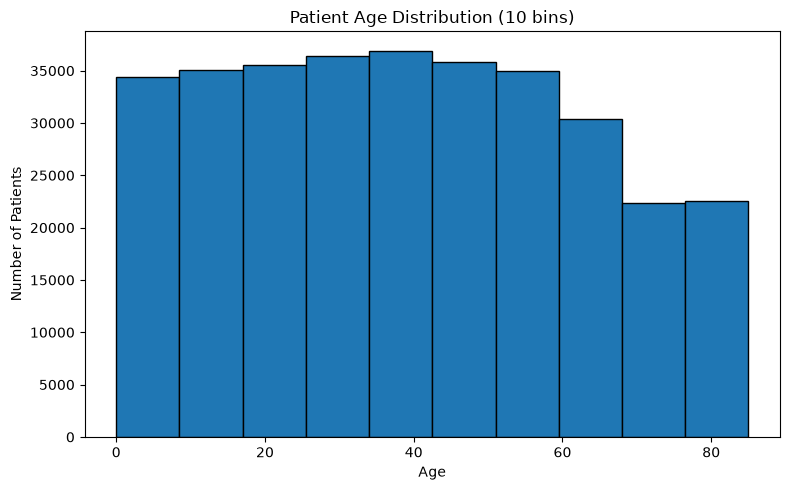

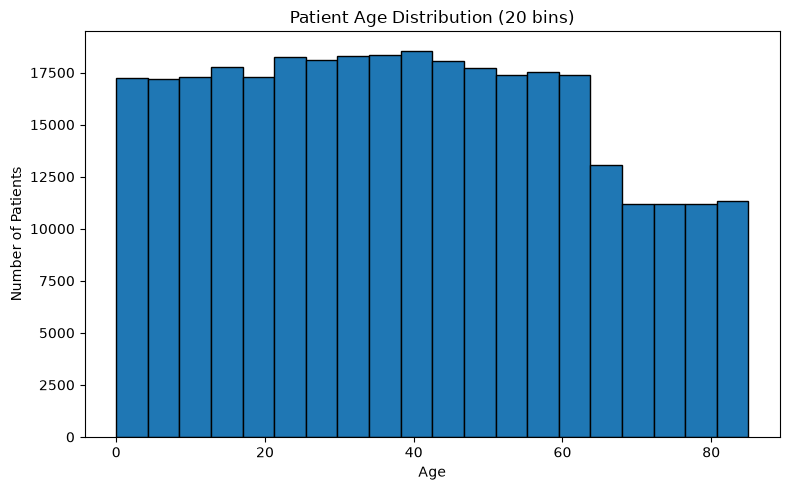

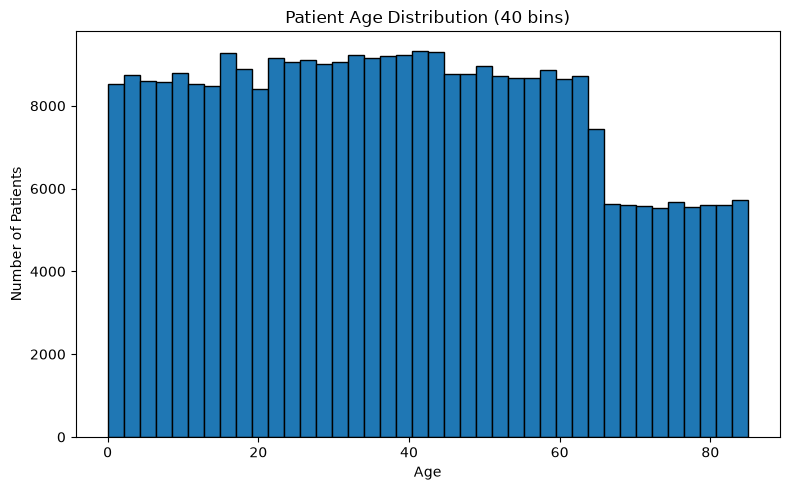

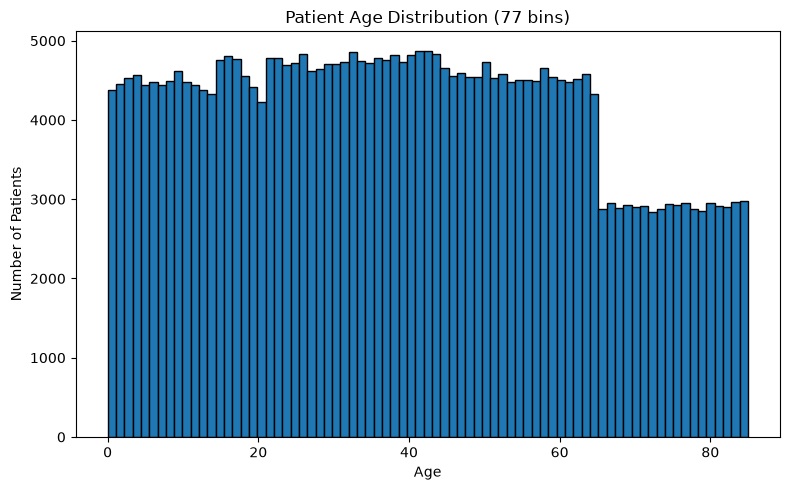

In [3]:
# ---------------------------
# 2. Explore histogram bins
# ---------------------------

for bins in [10, 20, 40, 77]:
    plt.figure(figsize=(8, 5))
    plt.hist(ages, bins=bins, edgecolor="black")

    plt.xlabel("Age")
    plt.ylabel("Number of Patients")
    plt.title(f"Patient Age Distribution ({bins} bins)")

    plt.tight_layout()
    plt.show()

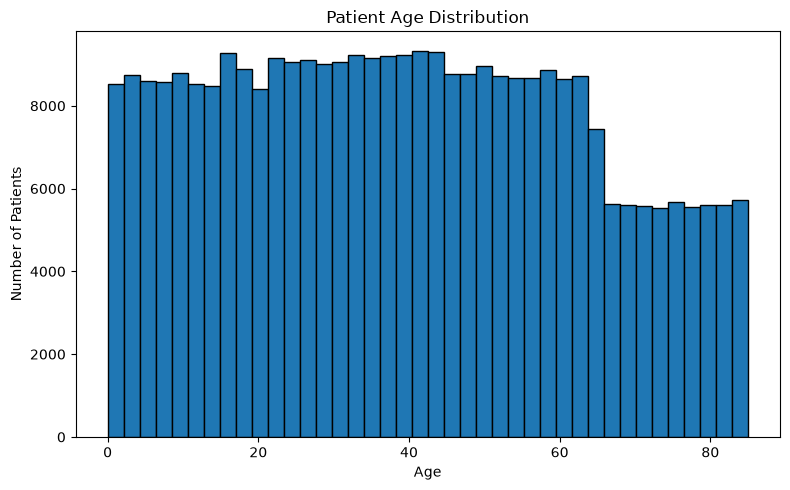

In [4]:
# ---------------------------
# 3. Final histogram
# ---------------------------

chosen_bins = 40

plt.figure(figsize=(8, 5))
plt.hist(ages, bins=chosen_bins, edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Patient Age Distribution")

plt.tight_layout()
plt.savefig("age_histogram.png", dpi=300)
plt.show()

In [5]:
# ---------------------------
# 4. Check exact duplicate ages
# ---------------------------

age_counts = Counter(age_strings)

duplicates = {
    age: count
    for age, count in age_counts.items()
    if count > 1
}

print("\nDuplicate analysis")
print("------------------")
print("Number of patients:", len(age_strings))
print("Number of unique exact ages:", len(age_counts))
print("Number of duplicated exact age values:", len(duplicates))
print("Maximum frequency:", max(age_counts.values()))

if duplicates:
    print("Duplicate ages:")
    for age, count in duplicates.items():
        print(age, count)
else:
    print("No exact duplicate ages were found.")


Duplicate analysis
------------------
Number of patients: 324357
Number of unique exact ages: 324357
Number of duplicated exact age values: 0
Maximum frequency: 1
No exact duplicate ages were found.


In [6]:
# ---------------------------
# 5. Binary search boundaries
# ---------------------------

sorted_ages = sorted(ages)

def find_age_range(sorted_values, target):
    """
    Return the first and last index containing target.
    Works even if duplicate values are present.
    """

    left = bisect_left(sorted_values, target)
    right = bisect_right(sorted_values, target)

    if left == right:
        return None

    return left, right - 1


# Example: search for an age that actually exists
target = ages[0]

result = find_age_range(sorted_ages, target)

print("\nBinary search example")
print("---------------------")
print("Target age:", target)
print("Boundary indices:", result)


Binary search example
---------------------
Target age: 19.529988374393394
Boundary indices: (79992, 79992)


Distinct gender categories: ['female', 'male', 'unknown']
Gender counts:
female 165293
male 158992
unknown 72


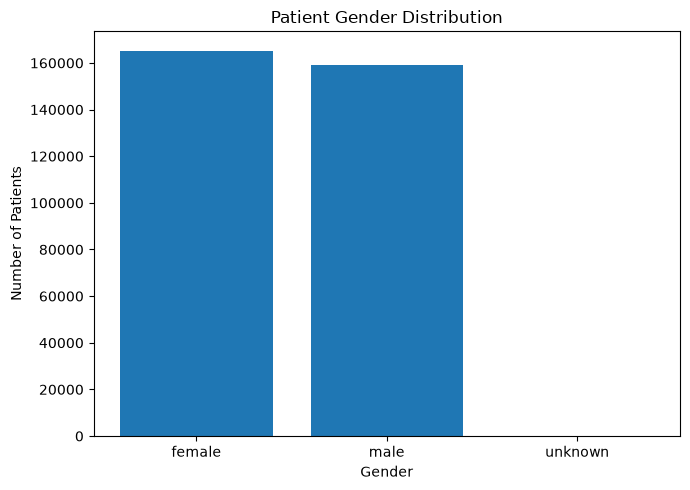

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

# ---------------------------
# 1b. Gender distribution
# ---------------------------

genders = [
    patient.get("gender")
    for patient in patients
    if patient.get("gender") is not None
]

gender_counts = Counter(genders)

print("Distinct gender categories:", sorted(gender_counts.keys()))
print("Gender counts:")

for gender, count in gender_counts.items():
    print(gender, count)


# Plot gender distribution
categories = list(gender_counts.keys())
counts = [gender_counts[g] for g in categories]

plt.figure(figsize=(7, 5))

plt.bar(categories, counts)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.title("Patient Gender Distribution")

plt.tight_layout()
plt.savefig("gender_distribution.png", dpi=300)
plt.show()

In [8]:
# ---------------------------
# 1c. Sort patients by age
# ---------------------------

patient_records = []

for patient in patients:
    patient_records.append({
        "name": patient.get("name"),
        "gender": patient.get("gender"),
        "age": float(patient.get("age"))
    })

# Sort from youngest to oldest
sorted_patients = sorted(
    patient_records,
    key=lambda patient: patient["age"]
)

print("Number of sorted patients:", len(sorted_patients))

# Look at the first few
print("\nYoungest patients:")
for patient in sorted_patients[:5]:
    print(patient)

# Look at the last few
print("\nOldest patients:")
for patient in sorted_patients[-5:]:
    print(patient)


# Oldest patient
oldest_patient = sorted_patients[-1]

print("\nOldest patient:")
print("Name:", oldest_patient["name"])
print("Age:", oldest_patient["age"])
print("Gender:", oldest_patient["gender"])

Number of sorted patients: 324357

Youngest patients:
{'name': 'Timothy Larson', 'gender': 'male', 'age': 0.00010629282758800596}
{'name': 'Lisa Dercole', 'gender': 'female', 'age': 0.0008606743639882897}
{'name': 'Julia Clinton', 'gender': 'female', 'age': 0.0011937231038899876}
{'name': 'Mauricio Pepin', 'gender': 'male', 'age': 0.0022482004795970623}
{'name': 'Peter Blalock', 'gender': 'male', 'age': 0.0025810199881115548}

Oldest patients:
{'name': 'Stephan Yeargin', 'gender': 'male', 'age': 84.99723990226988}
{'name': 'Michael Ali', 'gender': 'male', 'age': 84.99794285222339}
{'name': 'Tracy Walker', 'gender': 'female', 'age': 84.99820162144917}
{'name': 'Raymond Leigh', 'gender': 'male', 'age': 84.9982928781625}
{'name': 'Monica Caponera', 'gender': 'female', 'age': 84.99855742449432}

Oldest patient:
Name: Monica Caponera
Age: 84.99855742449432
Gender: female


In [9]:
# ---------------------------
# 1d. Find second-oldest patient in O(n)
# ---------------------------

oldest = None
second_oldest = None

for patient in patient_records:

    if oldest is None or patient["age"] > oldest["age"]:
        # The previous oldest becomes the second oldest
        second_oldest = oldest
        oldest = patient

    elif second_oldest is None or patient["age"] > second_oldest["age"]:
        second_oldest = patient


print("Oldest patient:")
print(oldest)

print("\nSecond-oldest patient:")
print(second_oldest)

Oldest patient:
{'name': 'Monica Caponera', 'gender': 'female', 'age': 84.99855742449432}

Second-oldest patient:
{'name': 'Raymond Leigh', 'gender': 'male', 'age': 84.9982928781625}


In [10]:
# ---------------------------
# 1e. Binary search for age 41.5
# ---------------------------

ages = [patient["age"] for patient in sorted_patients]


def lower_bound(values, target):
    """
    Find the first index where values[index] >= target.
    """
    left = 0
    right = len(values)

    while left < right:
        mid = (left + right) // 2

        if values[mid] < target:
            left = mid + 1
        else:
            right = mid

    return left


def upper_bound(values, target):
    """
    Find the first index where values[index] > target.
    """
    left = 0
    right = len(values)

    while left < right:
        mid = (left + right) // 2

        if values[mid] <= target:
            left = mid + 1
        else:
            right = mid

    return left


target = 41.5

first = lower_bound(ages, target)
last = upper_bound(ages, target)

if first < len(ages) and ages[first] == target:

    matches = sorted_patients[first:last]

    print(f"Found {len(matches)} patient(s) with age {target}:")

    for patient in matches:
        print(patient)

else:
    print(f"No patient has exact age {target}.")

    # first is the position where target would be inserted
    if first > 0:
        print("Closest age below:", sorted_patients[first - 1])

    if first < len(sorted_patients):
        print("Closest age above:", sorted_patients[first])

Found 1 patient(s) with age 41.5:
{'name': 'John Braswell', 'gender': 'male', 'age': 41.5}


In [11]:
# ---------------------------
# 1f. Count patients age >= 41.5
# ---------------------------

target = 41.5

first = lower_bound(ages, target)

count_at_least_target = len(ages) - first

print("First index with age >= 41.5:", first)
print("Total number of patients:", len(ages))
print("Patients age >= 41.5:", count_at_least_target)

First index with age >= 41.5: 173886
Total number of patients: 324357
Patients age >= 41.5: 150471


In [12]:
# ---------------------------
# 1g. Count patients in an age range
# low_age <= age < high_age
# ---------------------------

def count_age_range(ages, low_age, high_age):
    if high_age < low_age:
        raise ValueError("high_age must be greater than or equal to low_age")

    left = lower_bound(ages, low_age)
    right = lower_bound(ages, high_age)

    return right - left

In [ ]:
# ---------------------------
# 1h. Multi-criteria range query
# ---------------------------

# ages is already sorted from the previous tasks
ages = [patient["age"] for patient in sorted_patients]

# Build prefix sum for male patients
# male_prefix[i] = number of male patients among
# sorted_patients[0:i]
male_prefix = [0]

for patient in sorted_patients:
    is_male = 1 if patient["gender"] == "male" else 0
    male_prefix.append(male_prefix[-1] + is_male)


def count_age_range_by_gender(ages, male_prefix, low_age, high_age):
    if high_age < low_age:
        raise ValueError(
            "high_age must be greater than or equal to low_age"
        )

    # Age boundaries found with binary search
    left = lower_bound(ages, low_age)
    right = lower_bound(ages, high_age)

    # Total patients in [low_age, high_age)
    total_count = right - left

    # Male patients in [low_age, high_age)
    male_count = male_prefix[right] - male_prefix[left]

    return total_count, male_count